### IMEC2543 - DINAMICA DE MAQUINARIA
### [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/) Cod. 202321287
# Path Planning — Robot RR en MuJoCo

In [26]:
import numpy as np
from numpy import deg2rad, rad2deg
from sympy import symbols, pi, sin, cos, lambdify, solve, linear_eq_to_matrix, simplify, acos, sqrt, rad
import sympy as sp
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, express
from scipy import optimize
from scipy.optimize import fsolve
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

> **Nota:** Todos los recursos para esta actividad (imágenes adicionales, mediciones, archivos XML de MuJoCo) están disponibles en el repositorio: https://github.com/LuigiToby/IMEC2543

---
# Paso -1 — Estrategia general

Antes de escribir una sola línea de código, conviene tener clara la hoja de ruta. El problema pide hacer girar un brazo RR **360° en sentido horario** evitando un cubo verde, con el efector final pasando por detrás del obstáculo y el codo siempre por encima de él.

## Metodología

1. **Modelar el RR en Python** — Cinemática directa (FK), cinemática inversa (IK) y geometría de eslabones equivalente a la escena de MuJoCo.
2. **Analizar restricciones** — Giro 360° horario, efector detrás del cubo, codo sobre el cubo.
3. **Definir key-points** — Configuración inicial, puntos intermedios críticos y configuración final.
4. **Generar trayectoria** — Interpolación en joint space con perfiles suaves (quintic / smoothstep).
5. **Construir la trayectoria completa** — Unir fases verificando continuidad y validez en cada instante.
6. **Exportar a MuJoCo** — Definir $q_1(t)$ y $q_2(t)$, ejecutar con control PID + compensación de gravedad.
7. **Validar** — Sin colisiones, movimiento completo correcto.

---
# Paso 0 — Crear el robot RR

Este robot fue desarrollado originalmente para un bono de clase, así que lo reutilizo aquí.

Se definen los marcos de referencia con `sympy.physics.mechanics` para tener cinemática simbólica limpia. Los parámetros $AB = BC = 0.7$ m coinciden con los eslabones del modelo XML de MuJoCo.

In [27]:
# ── Símbolos simbólicos ───────────────────────────────────────────────────────
AB, BC, CD = symbols('AB, BC, CD')
theta1, theta2 = dynamicsymbols('theta1 theta2')

# Marcos de referencia: N inercial, A gira con q1, B gira con q2
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [theta1, N.z])
B = A.orientnew('B', 'Axis', [theta2, N.z])

# Longitudes de eslabón y radios (para chequeo de colisión con radio físico)
params   = {AB: 0.7, BC: 0.7}
radiol1  = 0.025   # radio de la cápsula del eslabón 1
radiol2  = 0.022   # radio de la cápsula del eslabón 2

# Obstáculo: caja verde centrada en (0.5, 0.2) con semiancho 0.10 en x e y
obs_center = (0.5, 0.2)
obs_half   = (0.10, 0.10)
x_min, x_max = 0.4, 0.6
y_min, y_max = 0.1, 0.3

# ── Cinemática directa simbólica ─────────────────────────────────────────────
r1 = AB * A.x          # vector eslabón 1 en marco A
r2 = BC * B.x          # vector eslabón 2 en marco B
eqLoop = r1 + r2       # posición del efector final

eqParams = eqLoop.subs(params)

# Función numérica [x, y] = f(q1, q2)
eq_fun = lambdify(
    [theta1, theta2],
    [eqParams.dot(N.x), eqParams.dot(N.y)]
)

display(eqLoop)
display(eqParams)
display([eqParams.dot(N.x), eqParams.dot(N.y)])

AB*A.x + BC*B.x

0.7*A.x + 0.7*B.x

[-0.7*sin(theta1(t))*sin(theta2(t)) + 0.7*cos(theta1(t))*cos(theta2(t)) + 0.7*cos(theta1(t)),
 0.7*sin(theta1(t))*cos(theta2(t)) + 0.7*sin(theta1(t)) + 0.7*sin(theta2(t))*cos(theta1(t))]

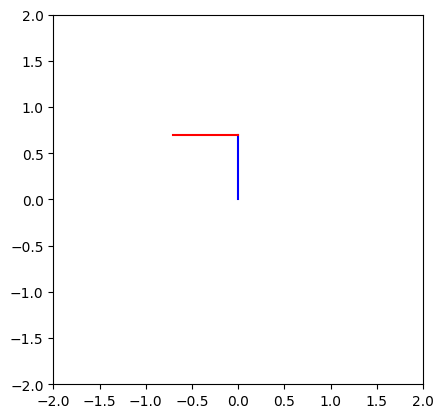

In [28]:
# Diccionario de funciones numéricas para cada punto del mecanismo.
# Para cada punto simbólico (A, B, C) se genera una función lambda que recibe
# (q1, q2) y devuelve las coordenadas cartesianas numéricas.
points = {'A': 0*N.x, 'B': r1, 'C': r1 + r2}
points_fun = {
    k: lambdify(
        [theta1, theta2],
        [v.dot(N.x).subs(params), v.dot(N.y).subs(params)]
    )
    for k, v in points.items()
}

def plotMechanism(joint_values, ax=None):
    """Versión básica: dibuja los eslabones como líneas de colores."""
    A = points_fun['A'](*joint_values)
    B = points_fun['B'](*joint_values)
    C = points_fun['C'](*joint_values)
    if ax is None:
        ax = plt.figure().add_subplot(111)
    ax.plot([A[0], B[0]], [A[1], B[1]], 'BLUE')
    ax.plot([B[0], C[0]], [B[1], C[1]], 'red')
    ax.set_aspect('equal')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

plotMechanism([np.deg2rad(90), np.deg2rad(90)])

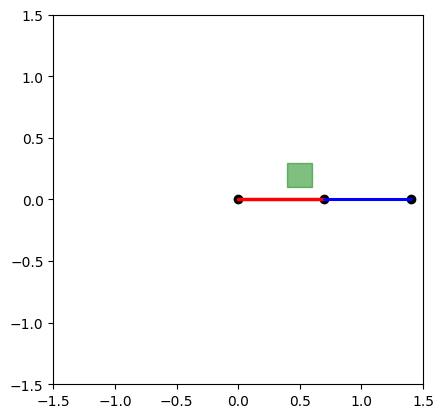

In [29]:
def plotMechanism2(joint_values, ax=None):
    """
    Versión mejorada: dibuja los eslabones con grosor proporcional al radio
    físico de las cápsulas y muestra el obstáculo verde.
    """
    A = np.array(points_fun['A'](*joint_values))
    B = np.array(points_fun['B'](*joint_values))
    C = np.array(points_fun['C'](*joint_values))

    if ax is None:
        fig, ax = plt.subplots()

    # Eslabón 1 (rojo)
    ax.plot([A[0], B[0]], [A[1], B[1]],
            linewidth=radiol1 * 100, color='red', solid_capstyle='round')

    # Eslabón 2 (azul)
    ax.plot([B[0], C[0]], [B[1], C[1]],
            linewidth=radiol2 * 100, color='blue', solid_capstyle='round')

    # Obstáculo
    rect = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                     color='green', alpha=0.5)
    ax.add_patch(rect)

    # Joints
    ax.scatter(A[0], A[1], color='black')
    ax.scatter(B[0], B[1], color='black')
    ax.scatter(C[0], C[1], color='black')

    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

plotMechanism2([np.deg2rad(0), np.deg2rad(0)])

In [30]:
# ── Cinemática directa e inversa numéricas ────────────────────────────────────

def FK(q):
    """Cinemática directa: devuelve [x, y] del efector dado [q1, q2]."""
    return np.array(eq_fun(q[0], q[1]))


def IK_error(q, target):
    """Función de costo para IK: suma de errores cuadráticos en cartesiano."""
    return np.square(FK(q) - target).sum()


def IK(target):
    """
    Cinemática inversa por optimización numérica (L-BFGS-B).
    Prueba múltiples semillas para evitar mínimos locales.
    """
    seeds = [
        [np.pi/2, np.pi/2]
    ]

    best_q   = None
    best_err = np.inf

    for q0 in seeds:
        res = minimize(IK_error, args=(target,), x0=q0, method='L-BFGS-B')
        err = IK_error(res.x, target)
        if err < best_err:
            best_err = err
            best_q   = res.x

    return best_q, best_err

FK: [ 1.00000001e+00 -5.36473432e-09]
Error: 1.7190071181044442e-16
q*: [-5.50799195  4.73279858]


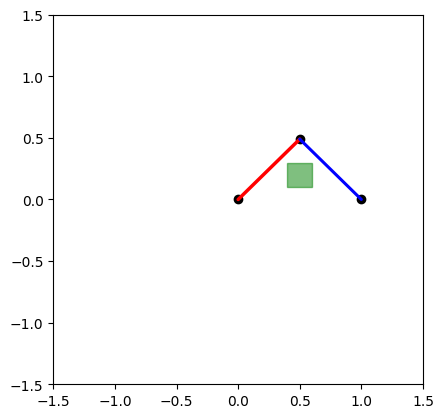

In [31]:
# Verificación rápida: ¿la IK encuentra el punto [1, 0]?
le_point = np.array([1, 0])
qstar, err = IK(le_point)

print("FK:", FK(qstar))
print("Error:", err)
print("q*:", qstar)
plotMechanism2([qstar[0], qstar[1]])

---
# Paso 1 — Identificar el espacio de trabajo

Antes de planear la trayectoria hay que saber **dónde puede ir el robot y dónde no**. Se hace un barrido completo del espacio de joints, se calcula la posición del efector para cada combinación $(q_1, q_2)$ y luego se filtran las configuraciones que producen colisión con la caja.

El rango de $q_1 \in [0°, 180°]$ se elige deliberadamente para forzar la solución con el **codo por encima del cubo** (elbow-up), que es la restricción del enunciado.

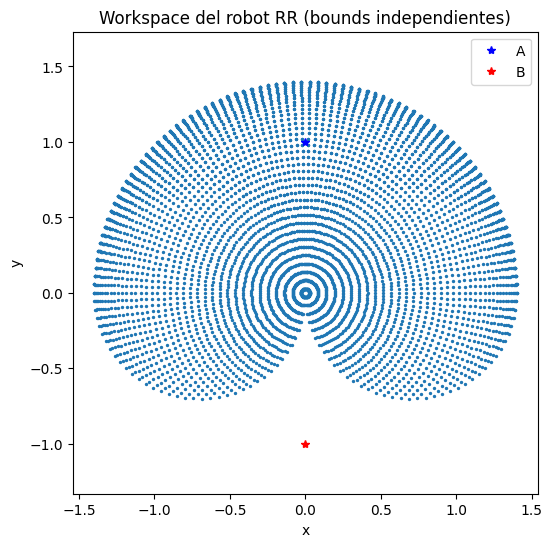

In [32]:
# Barrido del espacio de joints
theta1_vals = np.deg2rad(np.linspace(0, 180, 80))
theta2_vals = np.deg2rad(np.linspace(0, 360, 80))

th1_grid, th2_grid = np.meshgrid(theta1_vals, theta2_vals)

x_vals = np.zeros_like(th1_grid)
y_vals = np.zeros_like(th2_grid)

for i in range(th1_grid.shape[0]):
    for j in range(th1_grid.shape[1]):
        C = points_fun['C'](th1_grid[i, j], th2_grid[i, j])
        x_vals[i, j] = C[0]
        y_vals[i, j] = C[1]

# Visualización del workspace crudo (sin filtrar colisiones)
plt.figure(figsize=(6, 6))
plt.scatter(x_vals.flatten(), y_vals.flatten(), s=2)
plt.plot(0, 1.0,  'b*', label='A')
plt.plot(0, -1.0, 'r*', label='B')
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Workspace del robot RR (bounds independientes)')
plt.legend()
plt.show()

In [33]:
def segment_box_collision(P, Q, radius=0.0):
    """
    Detecta si el segmento PQ (con radio físico `radius`) intersecta la caja.

    Estrategia en dos pasos:
      1. Si algún extremo está dentro de la caja inflada → colisión directa.
      2. Si algún borde de la caja es cruzado por PQ → colisión por cruce.
    
    Inflar la caja por el radio del eslabón garantiza consistencia física.
    """
    # Caja inflada por el radio del brazo
    x0, x1 = x_min - radius, x_max + radius
    y0, y1 = y_min - radius, y_max + radius

    # Paso 1: extremo dentro de la caja
    if (x0 <= P[0] <= x1 and y0 <= P[1] <= y1) or \
       (x0 <= Q[0] <= x1 and y0 <= Q[1] <= y1):
        return True

    # Paso 2: test de intersección segmento-segmento (orientación CCW)
    def ccw(A, B, C):
        return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])

    def intersect(A, B, C, D):
        return ccw(A, C, D) != ccw(B, C, D) and ccw(A, B, C) != ccw(A, B, D)

    rect_edges = [
        ((x0, y0), (x1, y0)),
        ((x1, y0), (x1, y1)),
        ((x1, y1), (x0, y1)),
        ((x0, y1), (x0, y0))
    ]

    for E1, E2 in rect_edges:
        if intersect(P, Q, E1, E2):
            return True

    return False


def checkValidity(q1, q2):
    """
    Devuelve True si la configuración (q1, q2) es libre de colisión.
    Verifica ambos eslabones contra la caja, usando su radio físico.
    """
    A = np.array(points_fun['A'](q1, q2))
    B = np.array(points_fun['B'](q1, q2))
    C = np.array(points_fun['C'](q1, q2))

    if segment_box_collision(A, B, radiol1):
        return False
    if segment_box_collision(B, C, radiol2):
        return False

    return True

### Filtrar el workspace por colisión

Se hace el mismo barrido pero ahora clasificando cada configuración como válida o inválida. Esto genera el mapa de configuraciones libre-de-colisión que se usará después para A*.

In [34]:
theta1_vals = np.deg2rad(np.linspace(0, 180, 100))
theta2_vals = np.deg2rad(np.linspace(0, 360, 100))

th1_grid, th2_grid = np.meshgrid(theta1_vals, theta2_vals)

x_vals = np.zeros_like(th1_grid)
y_vals = np.zeros_like(th2_grid)

valid_configs = []
valid_x, valid_y     = [], []
invalid_x, invalid_y = [], []

for i in range(th1_grid.shape[0]):
    for j in range(th1_grid.shape[1]):
        q1 = th1_grid[i, j]
        q2 = th2_grid[i, j]

        C = points_fun['C'](q1, q2)
        x_vals[i, j] = C[0]
        y_vals[i, j] = C[1]

        if checkValidity(q1, q2):
            valid_configs.append([q1, q2])
            valid_x.append(C[0])
            valid_y.append(C[1])
        else:
            invalid_x.append(C[0])
            invalid_y.append(C[1])

valid_configs = np.array(valid_configs)

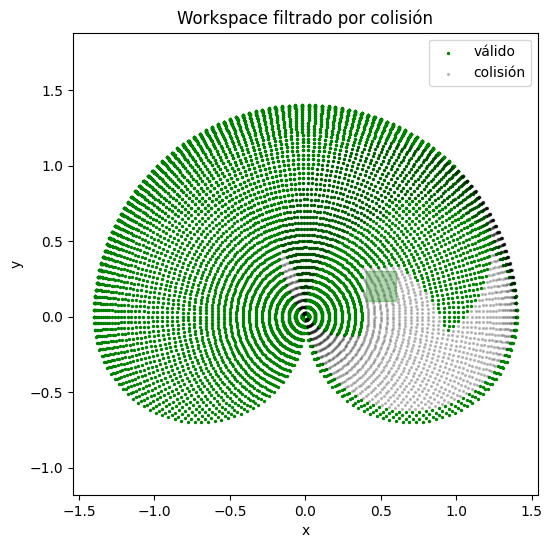

In [35]:
# Workspace filtrado: verde = válido, negro = colisión
plt.figure(figsize=(6, 6))
plt.scatter(valid_x,   valid_y,   s=2, color='green',          label='válido')
plt.scatter(invalid_x, invalid_y, s=2, color='black', alpha=0.2, label='colisión')
rect = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                 color='green', alpha=0.3)
plt.gca().add_patch(rect)
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Workspace filtrado por colisión')
plt.legend()
plt.show()

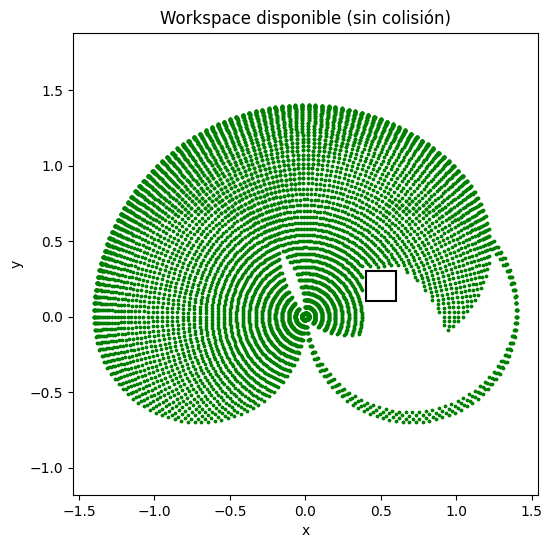

In [36]:
# Solo puntos válidos, con el contorno del obstáculo como referencia
plt.figure(figsize=(6, 6))
plt.scatter(valid_x, valid_y, s=3, color='green')
rect = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                 edgecolor='black', facecolor='none', linewidth=1.5)
plt.gca().add_patch(rect)
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Workspace disponible (sin colisión)')
plt.show()

---
# Paso 2a — Path Planning con splines

Primera aproximación: trayectorias en joint space con perfiles suaves (smoothstep y quintic). El objetivo es llevar el brazo sobre la caja en dos fases:

- **Fase 1:** rotación de $q_1$ de $0°$ a $300°$ con $q_2 = 0$ (eslabones alineados, gira sobre la caja).
- **Fase 2:** ajuste de $q_2$ con un polinomio de quinto grado para colocar el efector en la posición final deseada.

In [37]:
def trayectoria_fase1(t):
    """Fase 1: lleva el brazo sobre la caja girando q1 de 0 a 300°, q2=0."""
    T = 6.0
    t = np.clip(t, 0.0, T)
    s = t / T
    q1_d = (5*np.pi/3) * s   # 0 → 300°
    q2_d = 0.0
    return q1_d, q2_d


def get_end_effector(t):
    """Posición cartesiana del efector para un instante t en fase 1."""
    q1, q2 = trayectoria_fase1(t)
    return FK([q1, q2])


# Posición al final de la fase 1 → será el inicio de la fase 2
x_end, y_end = get_end_effector(6.0)
print(f"Posición final fase 1: x={x_end:.4f}, y={y_end:.4f}")

Posición final fase 1: x=0.7000, y=-1.2124


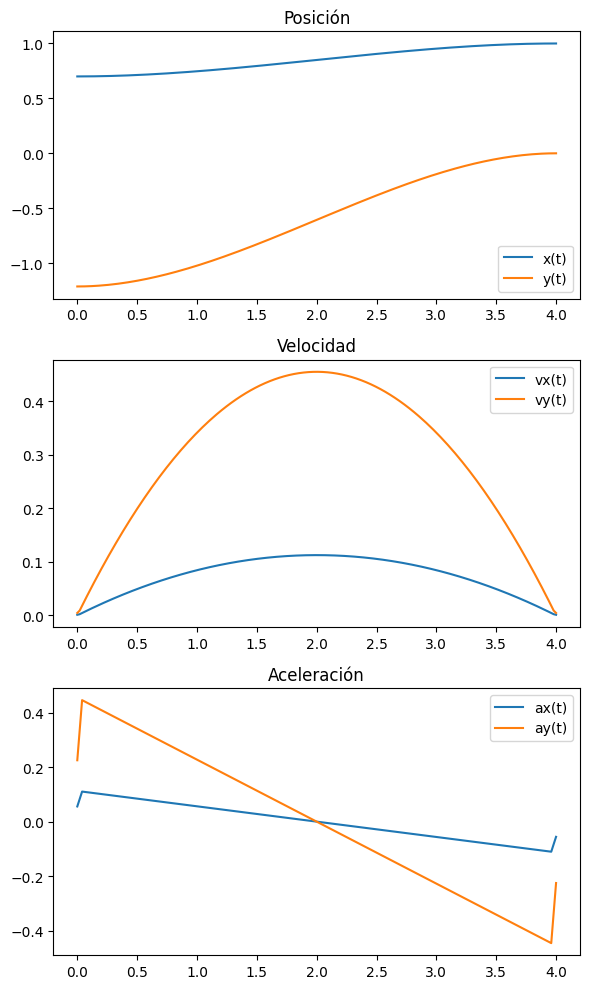

In [38]:
# ── Trayectoria cartesiana con smoothstep ─────────────────────────────────────
# Interpolación suave en el espacio cartesiano de p0 a pf.
# El smoothstep (3s²-2s³) garantiza velocidad cero en los extremos.

p0 = np.array([0.7, -1.212435565298214])   # fin de fase 1
pf = np.array([1.0,  0.0])                  # posición objetivo
T  = 4.0

def smoothstep(s):
    return 3*s**2 - 2*s**3

def trayectoria_cartesiana(t):
    t = np.clip(t, 0.0, T)
    s = smoothstep(t / T)
    return (1 - s)*p0 + s*pf

# Muestreo y derivadas numéricas
N_samples = 200
ts  = np.linspace(0, T, N_samples)
dt  = ts[1] - ts[0]
path = np.array([trayectoria_cartesiana(t) for t in ts])
vel  = np.gradient(path, dt, axis=0)
acc  = np.gradient(vel,  dt, axis=0)

fig, axs = plt.subplots(3, 1, figsize=(6, 10))
axs[0].plot(ts, path[:,0], label='x(t)'); axs[0].plot(ts, path[:,1], label='y(t)')
axs[0].set_title('Posición'); axs[0].legend()
axs[1].plot(ts, vel[:,0],  label='vx(t)'); axs[1].plot(ts, vel[:,1],  label='vy(t)')
axs[1].set_title('Velocidad'); axs[1].legend()
axs[2].plot(ts, acc[:,0],  label='ax(t)'); axs[2].plot(ts, acc[:,1],  label='ay(t)')
axs[2].set_title('Aceleración'); axs[2].legend()
plt.tight_layout()
plt.show()

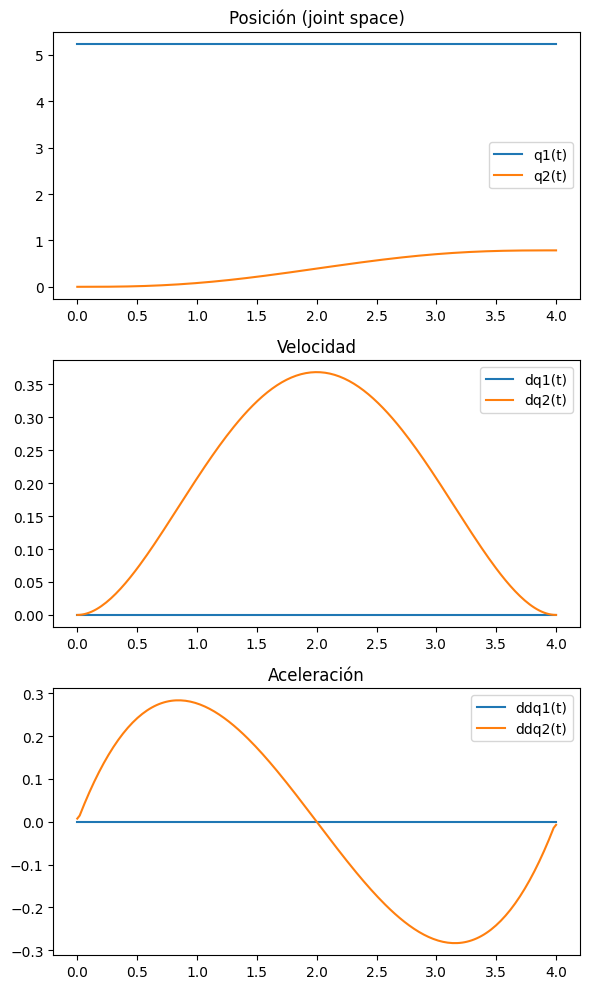

In [39]:
# ── Trayectoria en joint space con polinomio quintic ──────────────────────────
# El quintic (10u³ - 15u⁴ + 6u⁵) garantiza posición, velocidad Y aceleración
# continuas en los extremos (C2), lo que es ideal para evitar picos de torque.

q0_joint = np.array([5*np.pi/3, 0.0])      # 300°, 0°
qf_joint = np.array([5*np.pi/3, np.pi/4])  # 300°, 45°
T = 4.0

def quintic(u):
    return 10*u**3 - 15*u**4 + 6*u**5

def trayectoria_joint(t):
    t = np.clip(t, 0.0, T)
    s = quintic(t / T)
    return (1 - s)*q0_joint + s*qf_joint

ts    = np.linspace(0, T, 200)
dt    = ts[1] - ts[0]
traj  = np.array([trayectoria_joint(t) for t in ts])
vel   = np.gradient(traj, dt, axis=0)
acc   = np.gradient(vel,  dt, axis=0)

fig, axs = plt.subplots(3, 1, figsize=(6, 10))
axs[0].plot(ts, traj[:,0], label='q1(t)'); axs[0].plot(ts, traj[:,1], label='q2(t)')
axs[0].set_title('Posición (joint space)'); axs[0].legend()
axs[1].plot(ts, vel[:,0],  label='dq1(t)'); axs[1].plot(ts, vel[:,1],  label='dq2(t)')
axs[1].set_title('Velocidad'); axs[1].legend()
axs[2].plot(ts, acc[:,0],  label='ddq1(t)'); axs[2].plot(ts, acc[:,1],  label='ddq2(t)')
axs[2].set_title('Aceleración'); axs[2].legend()
plt.tight_layout()
plt.show()

In [40]:
def trayectoria(t):
    """
    Trayectoria completa en dos fases:
      - Fase 1 (0 → T1): q1 sube de 0 a 300°, q2 = 0.
      - Fase 2 (T1 → T1+T2): q2 sube de 0 a ~67.5° con quintic, q1 fijo.
    """
    T1 = 6.0
    T2 = 4.0
    T_total = T1 + T2

    t = np.clip(t, 0.0, T_total)

    def quintic(u):
        return 10*u**3 - 15*u**4 + 6*u**5

    if t <= T1:
        # Fase 1: rotación pura de q1
        s    = t / T1
        q1_d = (5*np.pi/3) * s
        q2_d = 0.0

    else:
        # Fase 2: ajuste de q2 con perfil quintic (C2 continuo)
        t2   = t - T1
        u    = np.clip(t2 / T2, 0.0, 1.0)
        s    = quintic(u)

        q0 = np.array([5*np.pi/3, 0.0])
        qf = np.array([5*np.pi/3, np.pi/2 + np.pi/16])   # ~67.5°

        q    = (1 - s)*q0 + s*qf
        q1_d, q2_d = q

    return q1_d, q2_d

---
# Justificación de la trayectoria seleccionada

## ¿Por qué interpolación en joint space y no en cartesiano?

La trayectoria final se define directamente en el espacio de joints $q_1(t)$ y $q_2(t)$, no en el espacio cartesiano del efector. Esto no es arbitrario: en un robot RR la cinemática inversa es no lineal, así que una línea recta en cartesiano **no** se traduce en una línea recta en joint space. Planear directamente en joints garantiza que los perfiles de posición, velocidad y aceleración sean exactamente los que se diseñan, sin distorsiones introducidas por la IK.

## Perfiles de movimiento: smoothstep y quintic

Se usaron dos perfiles distintos según el nivel de suavidad requerido en cada fase:

### Smoothstep — $s(u) = 3u^2 - 2u^3$

$$s(u) = 3u^2 - 2u^3, \quad u = \frac{t}{T}$$

Es un polinomio de tercer grado que cumple $s(0)=0$, $s(1)=1$ y $\dot{s}(0)=\dot{s}(1)=0$. Garantiza **continuidad $C^1$**: posición y velocidad continuas en los extremos, con velocidad cero al inicio y al final. Se usó en las transiciones de blending donde el requerimiento principal es evitar saltos de velocidad, sin necesidad de controlar la aceleración explícitamente.

### Quintic — $s(u) = 10u^3 - 15u^4 + 6u^5$

$$s(u) = 10u^3 - 15u^4 + 6u^5, \quad u = \frac{t}{T}$$

Es un polinomio de quinto grado que cumple adicionalmente $\ddot{s}(0)=\ddot{s}(1)=0$, logrando **continuidad $C^2$**: posición, velocidad *y aceleración* continuas en los extremos. Esto es crítico para la fase de ajuste de $q_2$, ya que una aceleración discontinua implica un salto de torque (por $\tau = M(q)\ddot{q} + \ldots$), lo que en la práctica genera picos que saturan los actuadores o excitan vibraciones en la estructura.

## Selección de A* como planificador global

Para la fase 2b se recurrió a A* sobre una malla cartesiana construida a partir del workspace libre de colisión. La justificación es directa: la trayectoria analítica no puede rodear el obstáculo de forma sistemática sin definir manualmente los puntos intermedios. A* explora el grafo del workspace y encuentra el camino de menor costo geométrico que respeta las restricciones, delegando el problema de evasión de obstáculos al algoritmo en lugar de resolverlo a mano. El resultado se convierte a joint space punto a punto con IK, propagando siempre $q_{prev}$ como semilla para garantizar continuidad y evitar saltos entre ramas de la solución.

---
## Simulación en MuJoCo — Control PID con compensación de gravedad

Se construye la escena en MuJoCo con el brazo RR y la caja verde. El controlador combina:
- **PID en feedback** para seguir la trayectoria de joints.
- **Feedforward de gravedad** (`qfrc_bias`) para compensar el peso estático de los eslabones y evitar que el brazo caiga.

El detector de colisión cambia el color de la caja a rojo en tiempo real si hay contacto con algún eslabón.

In [41]:
import mujoco
import mujoco.viewer
import numpy as np
import time

XML = r"""
<mujoco model="robot_RR_con_obstaculo">

  <compiler angle="degree"/>
  <option gravity="0 0 -9.81" timestep="0.002"/>

  <default>
    <joint damping="1" armature="0.01"/>
    <geom contype="1" conaffinity="1" friction="0.8 0.1 0.1" condim="3"/>
  </default>

  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
     rgb2=".2 .3 .4" width="300" height="300"/>
    <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
  </asset>

  <worldbody>
    <geom name="floor" type="plane" material="grid" size="5 5 5" pos="0 0 -1.5"/>
    <light pos="0 0 5" directional="true" diffuse="0.9 0.9 0.9" specular="0.1 0.1 0.1" dir="0 0 -1" castshadow="true"/>

    <!-- Base fija -->
    <body name="base" pos="0 0 0.05">
      <geom name="base_geom" type="box" size="0.04 0.04 0.04" rgba="0.3 0.3 0.3 1"/>

      <!-- Eslabón 1 -->
      <body name="link1" pos="0 0 0">
        <joint name="q1" type="hinge" axis="0 1 0" range="-360 360"/>
        <geom name="link1_geom" type="capsule" fromto="0 0 0 0.7 0 0.0"
              size="0.025" rgba="0.8 0.4 0.4 1"/>

        <!-- Eslabón 2 -->
        <body name="link2" pos="0.7 0 0">
          <joint name="q2" type="hinge" axis="0 1 0" range="-360 360"/>
          <geom name="link2_geom" type="capsule" fromto="0 0 0 0.7 0 0"
                size="0.022" rgba="0.4 0.4 0.8 1"/>
        </body>
      </body>
    </body>

    <!-- Obstáculo -->
    <body name="obstacle" pos="0.5 0 0.2">
      <geom name="box_obstacle" type="box" size="0.10 0.08 0.10" rgba="0.2 0.8 0.2 1"/>
    </body>
  </worldbody>

  <actuator>
    <!-- Actuadores de torque directo (sin transmisión) -->
    <motor joint="q1" ctrlrange="-200 200" gear="1"/>
    <motor joint="q2" ctrlrange="-200 200" gear="1"/>
  </actuator>

</mujoco>
"""


class PIDController:
    """
    PID discreto con:
      - Anti-windup por clamp en el término integral.
      - Derivada sobre la medición (no sobre el error) para evitar el
        'derivative kick' cuando el setpoint cambia abruptamente.
    """
    def __init__(self, kp, ki, kd, dt,
                 u_min=-200.0, u_max=200.0,
                 i_min=-50.0,  i_max=50.0):
        self.kp    = kp
        self.ki    = ki
        self.kd    = kd
        self.dt    = dt
        self.u_min = u_min
        self.u_max = u_max
        self.i_min = i_min
        self.i_max = i_max
        self._integral  = 0.0
        self._prev_meas = None

    def reset(self):
        self._integral  = 0.0
        self._prev_meas = None

    def compute(self, setpoint, measurement):
        error = setpoint - measurement

        # Integral con anti-windup
        self._integral += error * self.dt
        self._integral  = np.clip(self._integral, self.i_min, self.i_max)

        # Derivada sobre la medición
        if self._prev_meas is None:
            self._prev_meas = measurement
        d_term = -(measurement - self._prev_meas) / self.dt
        self._prev_meas = measurement

        u = self.kp * error + self.ki * self._integral + self.kd * d_term
        return float(np.clip(u, self.u_min, self.u_max))


def gravity_compensation(data):
    """
    Devuelve los torques necesarios para sostener el brazo contra la gravedad.
    Se lee directamente de `data.qfrc_bias`, que MuJoCo calcula internamente
    con la dinámica inversa. Esto es más preciso que aproximarlo analíticamente.
    """
    return data.qfrc_bias[:2].copy()


# ── Modelo y estado inicial ───────────────────────────────────────────────────
model = mujoco.MjModel.from_xml_string(XML)
data  = mujoco.MjData(model)

dt = model.opt.timestep   # 0.002 s

data.qpos[0] = 0.0
data.qpos[1] = 0.0
data.ctrl[0] = 0.0
data.ctrl[1] = 0.0
mujoco.mj_forward(model, data)

# ── Ganancias PID ─────────────────────────────────────────────────────────────
# Punto de partida conservador:
#   kp grande da tracking rápido, ki elimina error estático por gravedad,
#   kd amortigua oscilaciones.
pid1 = PIDController(kp=120.0, ki=25.0, kd=8.0, dt=dt)
pid2 = PIDController(kp=80.0,  ki=20.0, kd=5.0, dt=dt)

# ── IDs de geometría para detección de colisión ───────────────────────────────
box_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_GEOM, "box_obstacle")

def geom_name(geom_id):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)
    return name if name is not None else f"geom_{geom_id}"

def detect_box_contacts(model, data, box_id):
    """Retorna lista de contactos que involucran a la caja."""
    contacts = []
    for i in range(data.ncon):
        c = data.contact[i]
        if c.geom1 == box_id or c.geom2 == box_id:
            contacts.append(
                (geom_name(c.geom1), geom_name(c.geom2), np.array(c.pos))
            )
    return contacts


# ── Loop de simulación ────────────────────────────────────────────────────────
collision_events = []
collision_active = False

with mujoco.viewer.launch_passive(model, data) as viewer:
    start = time.time()

    while viewer.is_running() and time.time() - start < 200:
        with viewer.lock():
            t = data.time

            # 1. Referencia de la trayectoria
            q1_d, q2_d = trayectoria(t)

            # 2. Lectura de joints actuales
            q1 = data.qpos[0]
            q2 = data.qpos[1]

            # 3. Torque PID (feedback)
            tau1_fb = pid1.compute(q1_d, q1)
            tau2_fb = pid2.compute(q2_d, q2)

            # 4. Torque de compensación de gravedad (feedforward)
            tau_grav = gravity_compensation(data)

            # 5. Comando total = PID + gravedad
            data.ctrl[0] = tau1_fb + tau_grav[0]
            data.ctrl[1] = tau2_fb + tau_grav[1]

            mujoco.mj_step(model, data)

            # 6. Detección de colisión y feedback visual
            contacts = detect_box_contacts(model, data, box_id)

            if contacts:
                model.geom_rgba[box_id] = np.array([1.0, 0.0, 0.0, 1.0])  # rojo
            else:
                model.geom_rgba[box_id] = np.array([0.2, 0.8, 0.2, 1.0])  # verde

            if contacts and not collision_active:
                collision_active = True
                collision_events.append({"time": float(t), "contacts": contacts.copy()})
            elif not contacts:
                collision_active = False

        viewer.sync()
        time.sleep(dt)

# ── Reporte ───────────────────────────────────────────────────────────────────
print("\n===== COLLISION SUMMARY =====")
if not collision_events:
    print("No collision with the green box was detected.")
else:
    for k, event in enumerate(collision_events, start=1):
        print(f"\nCollision #{k} at t = {event['time']:.3f} s")
        for g1, g2, pos in event["contacts"]:
            print(f"  {g1} <-> {g2} at {pos}")


===== COLLISION SUMMARY =====
No collision with the green box was detected.


---
# Paso 2b — Path Planning con A*

Como alternativa al enfoque analítico, se usa A* sobre una malla cartesiana construida a partir del workspace válido. El algoritmo encuentra el camino más corto en el espacio cartesiano evitando automáticamente la zona de colisión.

El flujo es:
1. Discretizar el espacio cartesiano en una grilla 120×120.
2. Marcar cada celda como válida o inválida usando el workspace filtrado.
3. Correr A* de un punto de inicio a uno de destino.
4. Convertir el path cartesiano a joint space mediante IK.
5. Animar y exportar a MuJoCo.

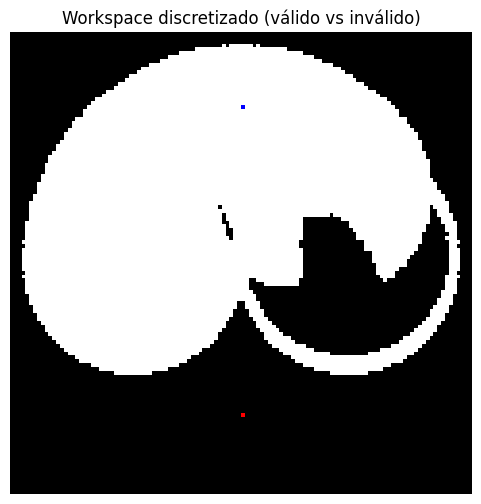

In [42]:
# ── Malla cartesiana y mapa binario ───────────────────────────────────────────
delta  = np.linspace(-1.5, 1.5, 120)
x_grid, y_grid = np.meshgrid(delta, delta)

pos = np.array([valid_x, valid_y])   # shape (2, N_validos)

def checkValidityXY(x, y, threshold=0.001):
    """
    Verifica si el punto (x, y) pertenece al workspace válido.
    Busca el punto más cercano en la nube de configuraciones válidas;
    si está a menos de `threshold`, se considera alcanzable.
    """
    dist2 = (pos[0] - x)**2 + (pos[1] - y)**2
    return np.min(dist2) < threshold

# Construir el mapa binario (1 = libre, 0 = ocupado)
valid_map = np.zeros_like(x_grid)
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        valid_map[i, j] = checkValidityXY(x_grid[i, j], y_grid[i, j])

# Mapeo posición → índice en la grilla
def pos_to_idx(pos):
    idx = np.floor(len(delta)*(pos - np.min(delta)) / (np.max(delta)-np.min(delta))).astype(int)
    return np.flip(idx)

# Puntos de referencia para visualización
pos_A = np.array([0,  1.0])
pos_B = np.array([0, -1.0])
idxA  = pos_to_idx(pos_A)
idxB  = pos_to_idx(pos_B)

# Visualización RGB del mapa
visuals = np.stack([valid_map, valid_map, valid_map], axis=2)
visuals[idxA[0], idxA[1], :] = [0, 0, 1]   # azul
visuals[idxB[0], idxB[1], :] = [1, 0, 0]   # rojo

plt.figure(figsize=(6, 6))
plt.imshow(np.flipud(visuals))
plt.title('Workspace discretizado (válido vs inválido)')
plt.axis('off')
plt.show()

In [43]:
from pathfinding.core.grid import Grid
from pathfinding.finder.a_star import AStarFinder
from pathfinding.core.diagonal_movement import DiagonalMovement

# Construir la grilla de pathfinding a partir del mapa binario
grid = Grid(matrix=valid_map.astype(int))

pos_start = np.array([-1.4,  0.0])
pos_goal  = np.array([ 1.0,  0.0])

idx_start = pos_to_idx(pos_start)
idx_goal  = pos_to_idx(pos_goal)

start = grid.node(idx_start[1], idx_start[0])
end   = grid.node(idx_goal[1],  idx_goal[0])

# Movimiento diagonal habilitado para paths más suaves
finder = AStarFinder(diagonal_movement=DiagonalMovement.always)
path, runs = finder.find_path(start, end, grid)

print("Path length:", len(path))

Path length: 97


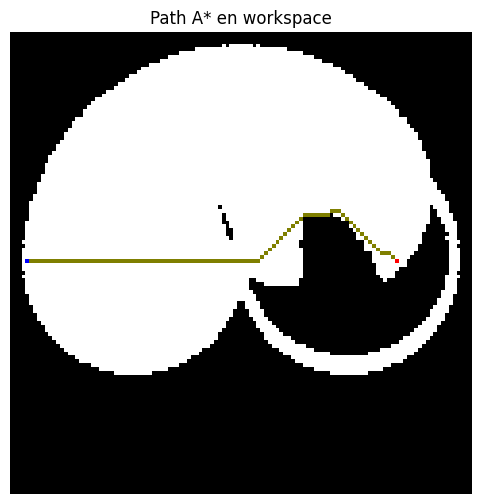

In [44]:
# Visualización del path sobre el mapa
visuals = np.stack([valid_map, valid_map, valid_map], axis=2)

for node in path:
    visuals[node.y, node.x, :] = [0.5, 0.5, 0]   # amarillo

visuals[idx_start[0], idx_start[1], :] = [0, 0, 1]
visuals[idx_goal[0],  idx_goal[1],  :] = [1, 0, 0]

plt.figure(figsize=(6, 6))
plt.imshow(np.flipud(visuals))
plt.title('Path A* en workspace')
plt.axis('off')
plt.show()

In [45]:
# ── Convertir path cartesiano → joint space (IK a lo largo del camino) ────────
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from scipy.interpolate import interp1d

path_xy = np.array([[delta[node.x], delta[node.y]] for node in path])

In [46]:
from scipy.optimize import minimize

def FK(q):
    return np.array(eq_fun(q[0], q[1]))

def IK_error(q, target):
    return np.square(FK(q) - target).sum()

def IK(target, q_prev):
    """
    IK con restricciones: q1 ∈ [0, π] para forzar solución elbow-up.
    Se inicializa desde q_prev para evitar saltos entre configuraciones
    consecutivas del path.
    """
    q_prev = np.array(q_prev).reshape(2,)
    bounds = [
        (0, np.pi),      # q1 restringido: codo sobre la caja
        (None, None)     # q2 libre
    ]
    res = minimize(
        IK_error, args=(target,),
        x0=q_prev, method='L-BFGS-B', bounds=bounds
    )
    return res.x, IK_error(res.x, target)

In [47]:
# Resolver IK a lo largo del path, propagando q_prev para continuidad
traj_q = []
q_prev = np.array([-np.pi, 0.0])   # semilla inicial

for x, y in path_xy:
    q, err = IK([x, y], q_prev)

    if err > 1e-3:
        print("Mala convergencia en:", x, y)
        break

    traj_q.append(q)
    q_prev = q   # propagar para evitar saltos

traj_q = np.array(traj_q)

# Unwrap para eliminar discontinuidades artificiales de ±2π
traj_q = np.unwrap(traj_q, axis=0)

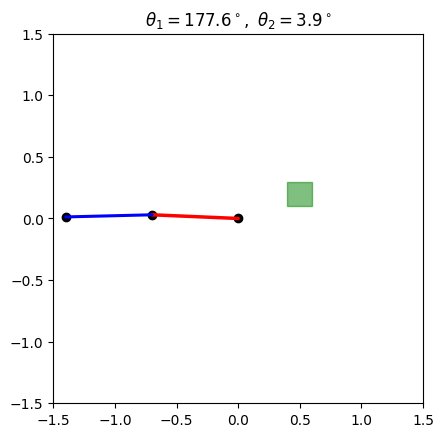

In [48]:
# Suavizado por interpolación y animación del path A*
t_old = np.linspace(0, 1, len(traj_q))
t_new = np.linspace(0, 1, 200)

q1 = interp1d(t_old, traj_q[:, 0], kind='linear')(t_new)
q2 = interp1d(t_old, traj_q[:, 1], kind='linear')(t_new)

traj_q = np.vstack([q1, q2]).T

fig, ax = plt.subplots()

def update(i):
    ax.clear()
    q1_i, q2_i = traj_q[i]
    plotMechanism2([q1_i, q2_i], ax)
    ax.set_title(
        rf"$\theta_1={np.rad2deg(q1_i):.1f}^\circ,\ "
        rf"\theta_2={np.rad2deg(q2_i):.1f}^\circ$"
    )
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')

anim = animation.FuncAnimation(
    fig, update, frames=len(traj_q), interval=60, repeat=False
)

HTML(anim.to_jshtml())

In [49]:
# ── Trayectoria completa para MuJoCo (A*) ────────────────────────────────────
# Se crean interpoladores sobre traj_q (normalizado en [0,1]) para poder
# evaluar la trayectoria A* en cualquier instante de tiempo.

t_path = np.linspace(0, 1, len(traj_q))
_interp_q1 = interp1d(t_path, traj_q[:, 0], kind='linear')
_interp_q2 = interp1d(t_path, traj_q[:, 1], kind='linear')

T_fase1 = 4.0    # fase 1: rotación de q1 de 0 a π
T_blend = 0.5    # blend: transición suave entre fase 1 y A*
T_fase2 = 6.0    # fase 2: seguir el path de A*
T_total  = T_fase1 + T_blend + T_fase2

def trayectoria(t):
    """
    Trayectoria completa con tres tramos:
      - Fase 1 (0 → T_fase1):             q1 de 0 a π, q2=0.
      - Blend (T_fase1 → T_fase1+T_blend): transición suave a inicio del path A*.
      - Fase 2 (resto):                    seguimiento del path A* en joint space.
    """
    t = np.clip(t, 0.0, T_total)

    def smoothstep(s):
        return 3*s**2 - 2*s**3

    if t <= T_fase1:
        s    = t / T_fase1
        q1_d = np.pi * s
        q2_d = 0.0

    elif t <= T_fase1 + T_blend:
        # Blend suave de la posición al final de fase 1 hasta el inicio del path A*
        s = smoothstep((t - T_fase1) / T_blend)
        q_start = np.array([np.pi, 0.0])
        q_end   = traj_q[0]
        q = (1 - s)*q_start + s*q_end
        q1_d, q2_d = q

    else:
        # Seguimiento del path A* con transformación continua de q1
        s      = np.clip((t - T_fase1 - T_blend) / T_fase2, 0.0, 1.0)
        q1_raw = float(_interp_q1(s))
        q2_d   = float(_interp_q2(s))
        q1_d   = np.pi + abs(q1_raw - np.pi)   # mantiene q1 continuo

    return q1_d, q2_d

In [50]:
# ── Trayectoria simplificada final (versión de entrega) ───────────────────────
# Versión limpia de una sola fase: q1 sube linealmente de 0 a π en 6 s, q2=0.
# Se usa como referencia base para el controlador de MuJoCo.

def trayectoria(t):
    T_total = 6.0
    t = np.clip(t, 0.0, T_total)
    s    = t / T_total
    q1_d = np.pi * s
    q2_d = 0.0
    return q1_d, q2_d